In [1]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

In [2]:
import os
os.chdir('..')
os.chdir('..')
os.getcwd()

'/Users/ak/Documents/GitHub/rise-project/pair_trading'

In [3]:
import numpy as np, random, os
import pandas as pd
from models import xgboost

np.random.seed(42)
random.seed(42)
os.environ["PYTHONHASHSEED"] = "42"

stock_pairs = [('JPM','AAPL'), 
         ('JPM','MA'), 
         ('JPM','GE'), 
         ('BRK-B','AAPL'), 
         ('BRK-B', 'MA'),
         ('BRK-B', 'GE'), 
         ('XOM','AAPL'), 
         ('XOM', 'MA'), 
         ('XOM','GE')]

tickers = sorted(set([stock for pair in stock_pairs for stock in pair]))

stock_train_prices = pd.read_csv("stocks/stock_train_prices.csv", index_col = 0, parse_dates = True)
stock_test_prices = pd.read_csv("stocks/stock_test_prices.csv", index_col = 0, parse_dates = True)

train_prices = stock_train_prices[tickers].dropna()
test_prices = stock_test_prices[tickers].dropna()

In [4]:
pair_models, pair_betas, feature_cols = xgboost.grid_search(stock_pairs, train_prices, test_prices)

Fitting 5 folds for each of 24 candidates, totalling 120 fits
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=5; total time=   0.1s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=1; total time=   0.2s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=5; total time=   0.3s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=1; total time=   0.3s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=1; total time=   0.4s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=1; total time=   0.4s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=1; total time=   0.4s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=5; total time=   0.3s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=5; total time=   0.3s
[CV] END gamma=0, learning_rate=0.01, max_depth=6, min_child_weight=1; total time=   0.3s
[CV] END gamma=0, learning_rate=0.01, 

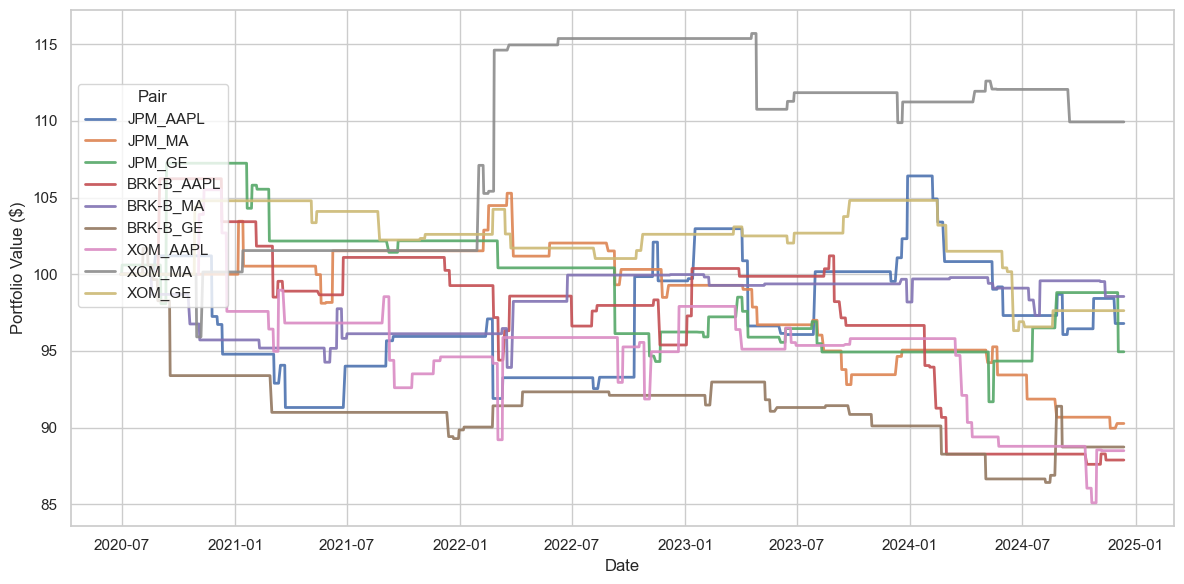

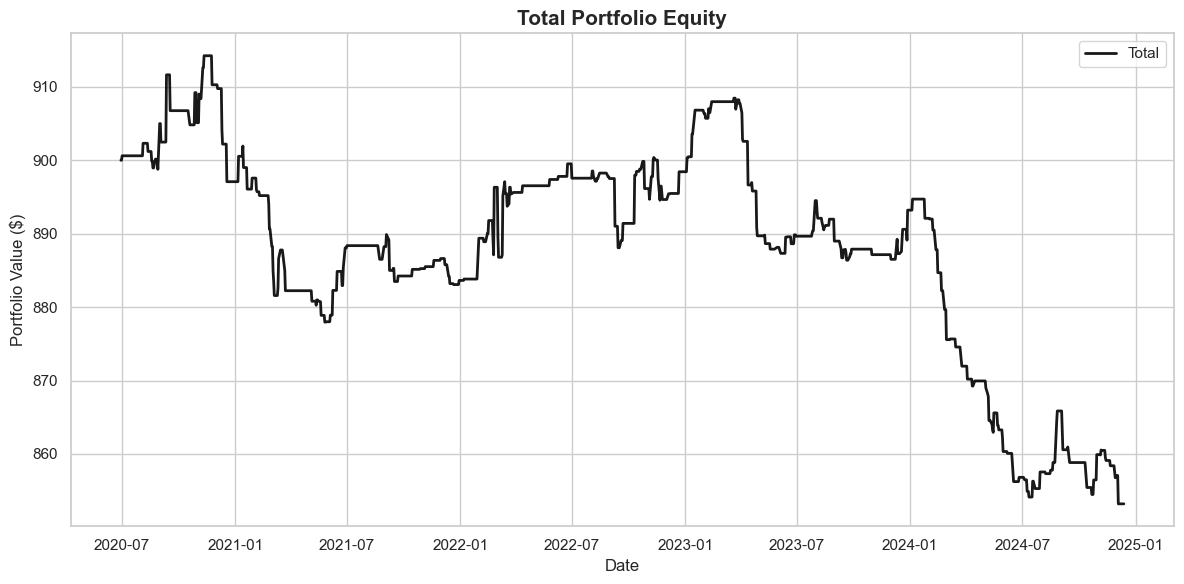

Summary
JPM_AAPL: Final Value = $96.79, Total Return = -3.21%, Trades = 41
JPM_MA: Final Value = $90.27, Total Return = -9.73%, Trades = 34
JPM_GE: Final Value = $94.94, Total Return = -5.06%, Trades = 30
BRK-B_AAPL: Final Value = $87.88, Total Return = -12.12%, Trades = 35
BRK-B_MA: Final Value = $98.55, Total Return = -1.45%, Trades = 28
BRK-B_GE: Final Value = $88.73, Total Return = -11.27%, Trades = 27
XOM_AAPL: Final Value = $88.49, Total Return = -11.51%, Trades = 39
XOM_MA: Final Value = $109.94, Total Return = 9.94%, Trades = 20
XOM_GE: Final Value = $97.63, Total Return = -2.37%, Trades = 27

Total Portfolio Performance
Initial Portfolio Value: $900.00
Final Portfolio Value:   $853.21
Total Return:            -5.20%

Sharpe Ratios
JPM_AAPL: Sharpe Ratio = -0.06
JPM_MA: Sharpe Ratio = -0.50
JPM_GE: Sharpe Ratio = -0.14
BRK-B_AAPL: Sharpe Ratio = -0.46
BRK-B_MA: Sharpe Ratio = -0.07
BRK-B_GE: Sharpe Ratio = -0.56
XOM_AAPL: Sharpe Ratio = -0.30
XOM_MA: Sharpe Ratio = 0.37
XOM_GE:

In [5]:
xgboost.run_simulation(stock_pairs, test_prices, pair_models, feature_cols, pair_betas)